In [3]:
!wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

In [4]:
import cv2
print('Open Cv version..')
print(cv2.__file__)
print(cv2.__version__)

Open Cv version..
/home/sureshkj/anaconda3/lib/python3.10/site-packages/cv2/__init__.py
4.10.0


In [5]:
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np


def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected poses to visualize.
  for idx in range(len(pose_landmarks_list)):
    pose_landmarks = pose_landmarks_list[idx]

    # Draw the pose landmarks.
    pose_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
    pose_landmarks_proto.landmark.extend([
      landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in pose_landmarks
    ])
    solutions.drawing_utils.draw_landmarks(
      annotated_image,
      pose_landmarks_proto,
      solutions.pose.POSE_CONNECTIONS,
      solutions.drawing_styles.get_default_pose_landmarks_style())
  return annotated_image

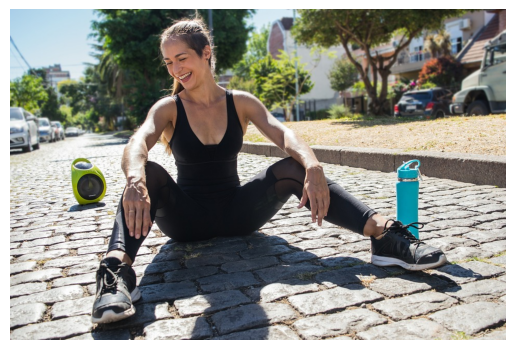

In [6]:
!wget -q -O image.jpg https://cdn.pixabay.com/photo/2019/03/12/20/39/girl-4051811_960_720.jpg

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg")

# Convert BGR to RGB (matplotlib expects images in RGB format)
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(image_rgb)
plt.axis('off')  # Turn off the axis
plt.show()

I0000 00:00:1738005760.423056   31104 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 4
I0000 00:00:1738005760.431640   43805 gl_context.cc:357] GL version: 3.1 (OpenGL ES 3.1 Mesa 20.0.8), renderer: llvmpipe (LLVM 10.0.0, 128 bits)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1738005760.525573   43807 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1738005760.617386   43817 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1738005760.732847   43818 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


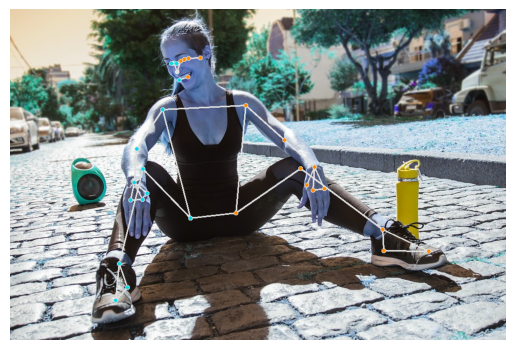

In [7]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("image.jpg")

# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)

# Convert BGR to RGB (matplotlib expects images in RGB format)
image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(image_rgb)
plt.axis('off')  # Turn off the axis
plt.show()

In [8]:
import json

# Extract pose landmarks
if detection_result.pose_landmarks:
    frame_results = []
    for landmark in detection_result.pose_landmarks[0]:
        frame_results.append({
            'x': landmark.x,
            'y': landmark.y,
            'z': landmark.z,
            'visibility': landmark.visibility
        })

with open('pose_results.json', 'w') as f:
    json.dump(frame_results, f)

In [6]:
print(type(detection_result))

<class 'mediapipe.tasks.python.vision.pose_landmarker.PoseLandmarkerResult'>
